In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# For better plot display
sns.set(style="whitegrid", palette="coolwarm")

In [ ]:
df = pd.read_csv('/content/crime_dataset_india.csv')

print("Dataset loaded successfully!")
display(df.head())

print("\nShape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00



Shape of dataset: (40160, 14)

Columns:
['Report Number', 'Date Reported', 'Date of Occurrence', 'Time of Occurrence', 'City', 'Crime Code', 'Crime Description', 'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain', 'Police Deployed', 'Case Closed', 'Date Case Closed']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       40160 non-null  int64 
 1   Date Reported       40160 non-null  object
 2   Date of Occurrence  40160 non-null  object
 3   Time of Occurrence  40160 non-null  object
 4   City                40160 non-null  object
 5   Crime Code          40160 non-null  int64 
 6   Crime Description   40160 non-null  object
 7   Victim Age          40160 non-null  int64 
 8   Victim Gender       40160 non-null  object
 9   Weapon Used         34370 non-null  object
 10  Crime Domain        40160 non-null  object
 11  Police Deployed     40160 non-null  int64 
 12  Case Closed         40160 non-null  object
 13  Date Case Closed    20062 non-null  object
dtypes: int64(4), object(10)
memory usage: 4.3+ MB

Missing Values per Column:
Report Number             0
Date Reported   

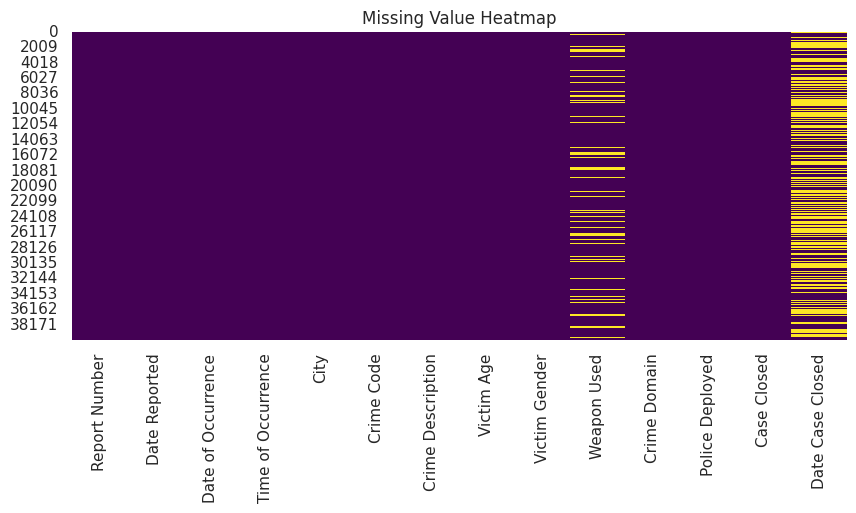

In [ ]:
df.info()

print("\nMissing Values per Column:")
print(df.isnull().sum())

# Visualize missing values
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

In [ ]:
# Fill numeric columns with median, categorical with mode
for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled.")

Missing values handled.


In [82]:
drop_cols = ['Report Number', 'Date Reported', 'Date of Occurrence',
             'Time of Occurrence', 'Date Case Closed']

df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)
print("Dropped unnecessary date/time columns (if present).")

Dropped unnecessary date/time columns (if present).


In [83]:
print(df.columns)

Index(['City', 'Crime Code', 'Crime Description', 'Victim Age',
       'Victim Gender', 'Weapon Used', 'Crime Domain', 'Police Deployed',
       'Case Closed'],
      dtype='object')


## **Visualisations**

In [ ]:
# Define custom colors
crime_domain_colors = {
    'Violent Crime': '#E63946',  # Red
    'Other Crime': '#457B9D',    # Blue
    'Property Crime': '#F4A261', # Orange
    'Cyber Crime': '#2A9D8F',    # Teal
    'White Collar Crime': '#8ECAE6' # Light Blue
}

gender_colors = {'M': '#89CFF0', 'F': '#F4C2C2', 'X': '#E6E6FA'} # Updated colors: Baby Blue for M, Baby Pink for F, Lavender for X
weapon_colors = {
    'Firearm': '#FF9F1C',
    'Blunt Object': '#2EC4B6',
    'Poison': '#E71D36',
    'Other': '#9D4EDD'
}

**(a) Distribution of Crime Domain**

/tmp/ipython-input-4042917787.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Crime Domain', data=df, order=domain_order, palette=colors)


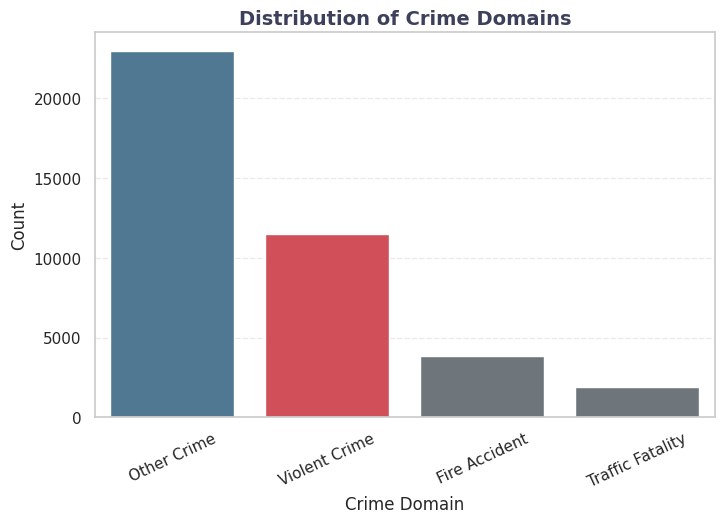

In [ ]:
plt.figure(figsize=(8,5))
domain_order = df['Crime Domain'].value_counts().index
colors = [crime_domain_colors.get(x, '#6C757D') for x in domain_order]
sns.countplot(x='Crime Domain', data=df, order=domain_order, palette=colors)
plt.title("Distribution of Crime Domains", fontsize=14, fontweight='bold', color='#3D405B')
plt.xlabel("Crime Domain", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

**(b) Crimes by City**

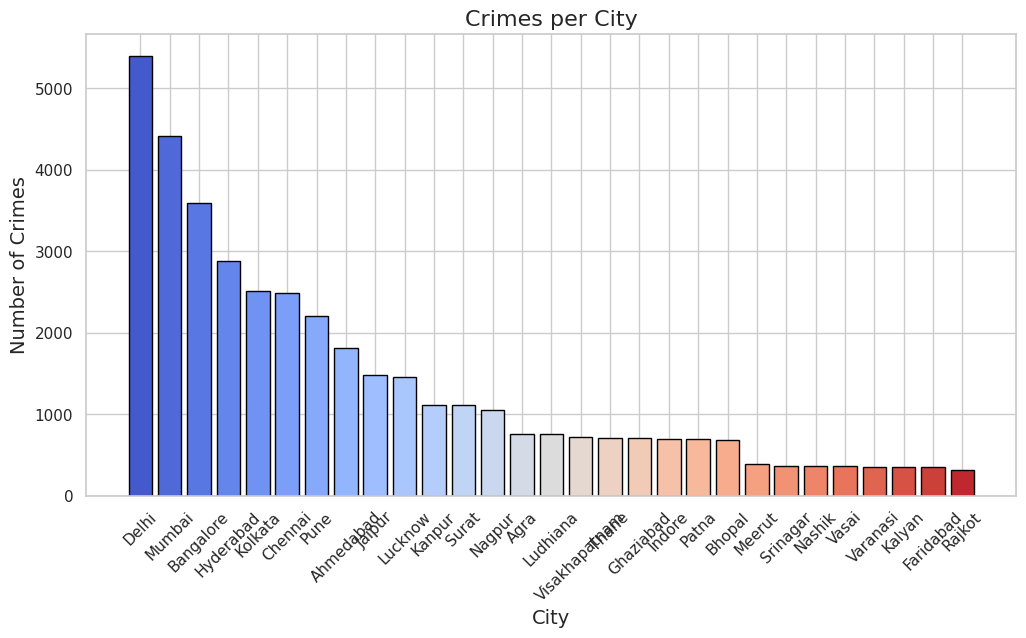

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

city_crimes = df['City'].value_counts()  # Counts of crimes per city

plt.figure(figsize=(12,6))
bar_colors = sns.color_palette("coolwarm", len(city_crimes))  # Custom gradient colors

bars = plt.bar(city_crimes.index, city_crimes.values, color=bar_colors, edgecolor='black')
plt.title("Crimes per City", fontsize=16)
plt.xlabel("City", fontsize=14)
plt.ylabel("Number of Crimes", fontsize=14)
plt.xticks(rotation=45)
plt.show()


**(c) Victim Age Distribution**

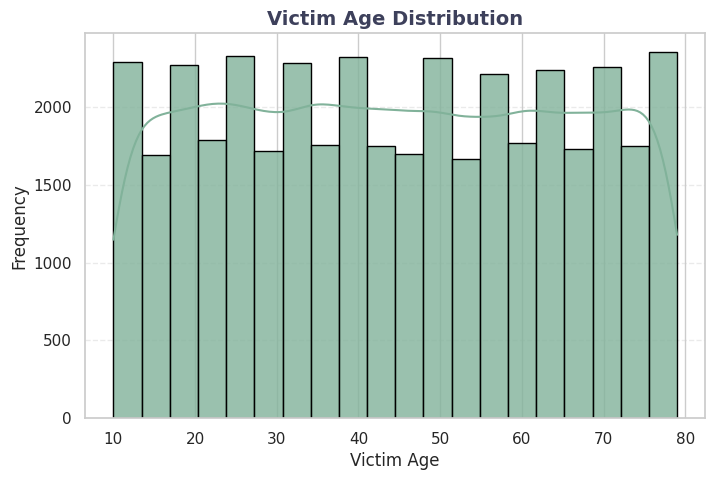

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Victim Age'], kde=True, bins=20, color="#81B29A", edgecolor='black', alpha=0.8)
plt.title("Victim Age Distribution", fontsize=14, fontweight='bold', color='#3D405B')
plt.xlabel("Victim Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

**(d) Victim Gender Count**

In [ ]:
print("Current gender_colors dictionary:")
print(gender_colors)

print("\nUnique values in 'Victim Gender' column and their counts:")
print(df['Victim Gender'].value_counts())

Current gender_colors dictionary:
{'M': '#89CFF0', 'F': '#F4C2C2', 'X': '#E6E6FA'}

Unique values in 'Victim Gender' column and their counts:
Victim Gender
F    22423
M    13405
X     4332
Name: count, dtype: int64


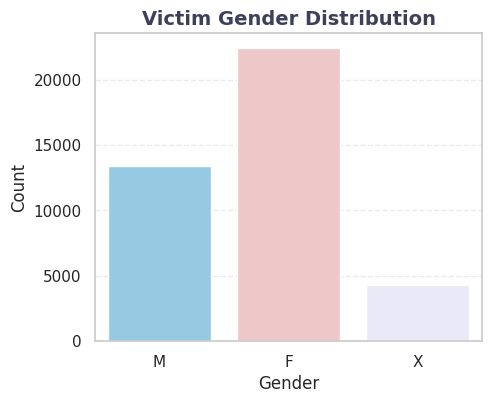

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x='Victim Gender', data=df, hue='Victim Gender', palette=gender_colors, legend=False)
plt.title("Victim Gender Distribution", fontsize=14, fontweight='bold', color='#3D405B')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

**(e) Distribution of Weapon Used**

/tmp/ipython-input-3025142469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weapon Used', data=df, order=weapon_order, palette=weapon_bar_colors)


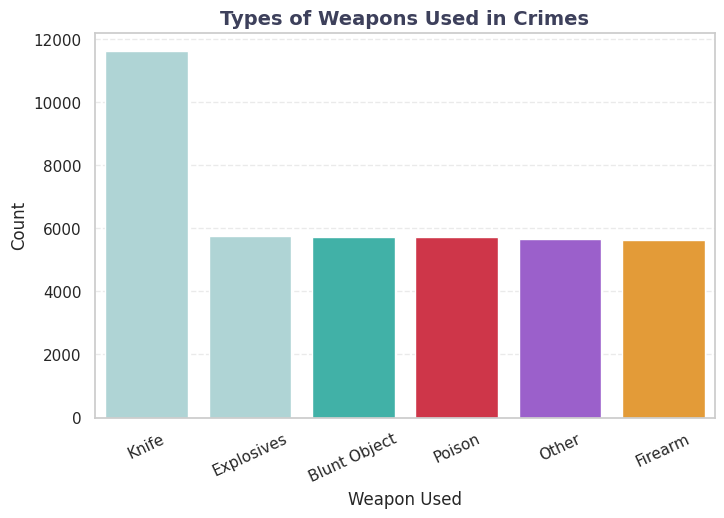

In [ ]:
plt.figure(figsize=(8,5))
weapon_order = df['Weapon Used'].value_counts().index
weapon_bar_colors = [weapon_colors.get(x, '#A8DADC') for x in weapon_order]
sns.countplot(x='Weapon Used', data=df, order=weapon_order, palette=weapon_bar_colors)
plt.title("Types of Weapons Used in Crimes", fontsize=14, fontweight='bold', color='#3D405B')
plt.xlabel("Weapon Used", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [ ]:
label_enc = LabelEncoder()
cat_cols = ['City', 'Crime Description', 'Victim Gender',
            'Weapon Used', 'Crime Domain', 'Case Closed']

for col in cat_cols:
    df[col] = label_enc.fit_transform(df[col])

print("Categorical features encoded successfully.")

Categorical features encoded successfully.


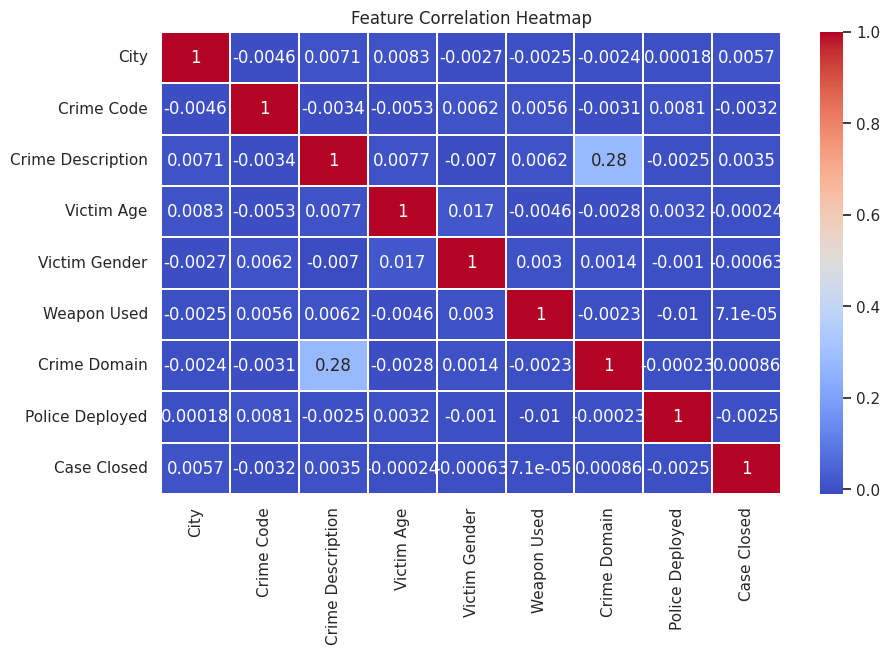

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.3)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop('Case Closed', axis=1)
y = df['Case Closed']

print("Features and target separated.")

Features and target separated.


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Data scaled and split successfully.")

Data scaled and split successfully.


In [ ]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
y_pred = svm_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 50.78 %

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.49      0.50      4046
           1       0.50      0.52      0.51      3986

    accuracy                           0.51      8032
   macro avg       0.51      0.51      0.51      8032
weighted avg       0.51      0.51      0.51      8032



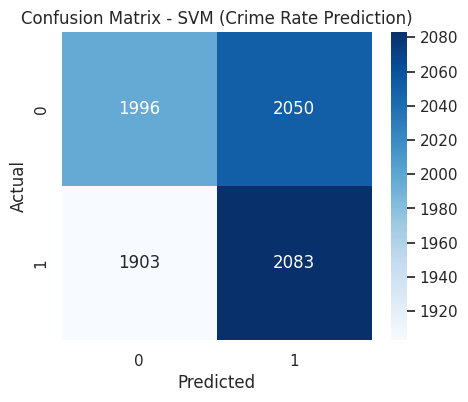

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM (Crime Rate Prediction)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Additional Visual Insights**

**(a) Case Closure Rate by City**

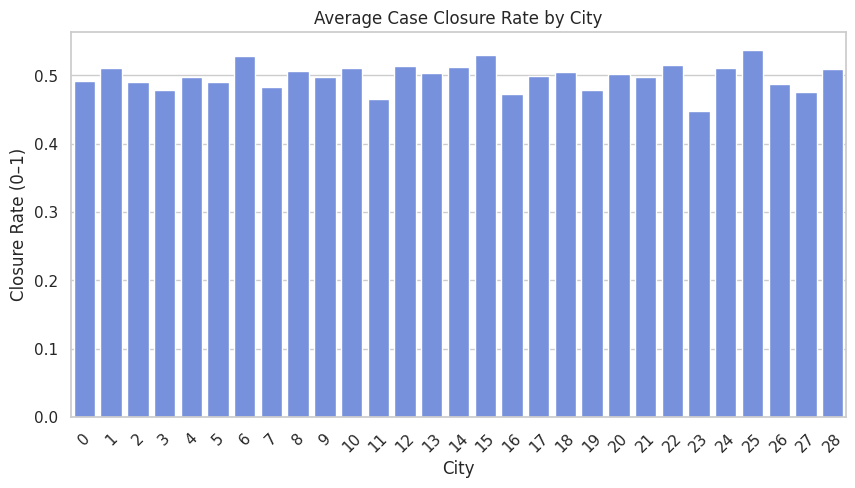

In [ ]:
city_rate = df.groupby('City')['Case Closed'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=city_rate.index, y=city_rate.values)
plt.title("Average Case Closure Rate by City")
plt.xticks(rotation=45)
plt.ylabel("Closure Rate (0–1)")
plt.show()

**(b) Average Police Deployed per Crime Type**

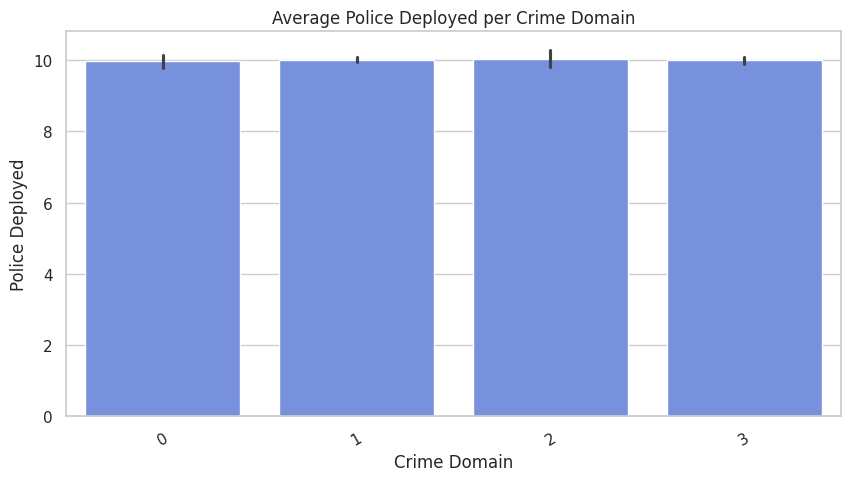

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Crime Domain', y='Police Deployed', data=df, estimator=np.mean)
plt.title("Average Police Deployed per Crime Domain")
plt.xticks(rotation=30)
plt.show()

**(c) Victim Age vs Police Deployed**

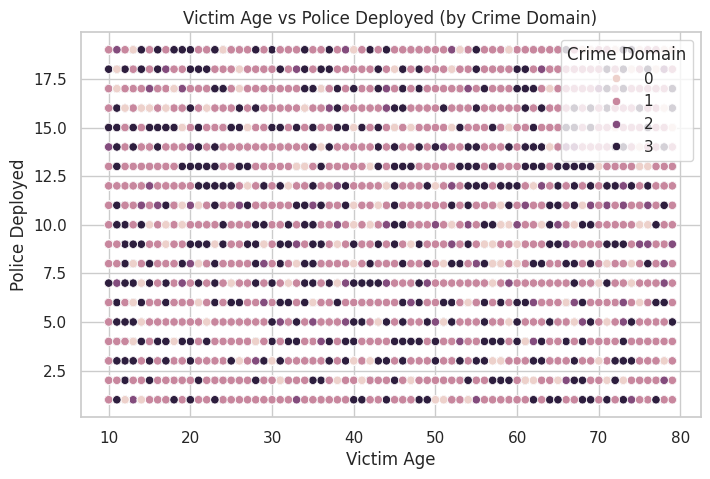

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Victim Age', y='Police Deployed', hue='Crime Domain', data=df)
plt.title("Victim Age vs Police Deployed (by Crime Domain)")
plt.show()

In [ ]:
import pickle

with open('SVM.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

In [ ]:
from google.colab import files
files.download('SVM.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**📊Summary:**
- **Preprocessed and visualized crime dataset**
- **Encoded categorical data**
- **Trained SVM model (RBF kernel)**
- **Evaluated performance via accuracy and confusion matrix**
- **Explored multiple visual insights on city, weapon, and crime patterns**